In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Data Load
df = pd.read_csv("q3_retail_promotions.csv")

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [3]:
# Date Feature Engineering
# Convert to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Extract features
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek

# Month-end flag
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

# Check output
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [4]:
# Temporal Train Test Split
# Sort by date
df = df.sort_values("transaction_date")

# Split index
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (960, 13)
Test size: (240, 13)


Why random split is wrong:

Time-based data has temporal dependency
Random split causes data leakage from future into past
Model learns patterns it shouldn't know
Temporal split simulates real-world prediction

In [5]:
# Prepare Features
target = "items_sold"

X_train = train_df.drop(columns=[target, "transaction_date"])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, "transaction_date"])
y_test = test_df[target]

In [6]:
# Preprocessing Pipeline
categorical_cols = ["promotion_type", "location_type", "store_size"]
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numerical_cols)
])

In [7]:
# Modal Training and Evaluation
# Linear Regression pipeline
lr_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.121451164890637
Linear Regression MAE: 21.052926674588395


In [8]:
# Modal Training and Evaluation
# Random forest pipeline
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 30.841610008504205
Random Forest MAE: 24.240625


In [9]:
# Parity Plot
def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    
    # diagonal line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

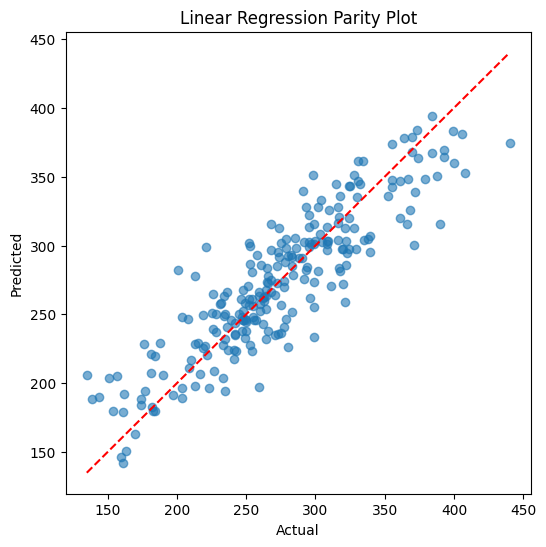

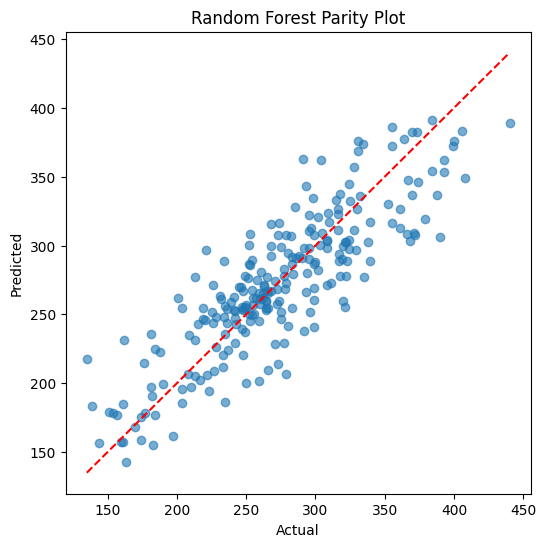

In [10]:
parity_plot(y_test, y_pred_lr, "Linear Regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random Forest Parity Plot")

In [11]:
# Feature Importances
# Get feature names after preprocessing
ohe = rf_pipeline.named_steps["preprocessing"].named_transformers_["cat"]
encoded_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_features) + numerical_cols

importances = rf_pipeline.named_steps["model"].feature_importances_

feat_importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_importance_df.head(5)

,feature,importance
13,is_festival,0.173473
10,store_size_small,0.167683
7,location_type_urban,0.108378
17,day_of_week,0.086316
12,is_weekend,0.061208


1. is_festival is the most important feature, indicating that sales significantly increase during festival periods due to higher customer demand and seasonal buying behaviour.
2. store_size_small being highly influential suggests that smaller stores in this dataset may experience distinct sales patterns — possibly due to focused inventory or higher turnover in specific locations.
3. location_type_urban shows that urban stores contribute strongly to sales, likely due to higher population density and customer traffic.
4. day_of_week indicates that sales vary across different days, capturing weekly shopping behaviour patterns.
5. is_weekend further reinforces that weekends drive higher sales compared to weekdays, aligning with typical consumer habits.